## gwModels kick velocity models

- **gwModel_kick_q200** : aligned-spin analytical kick model trained on NR (SXS + RIT, $q \leq 32$) and BHPT data ($q \leq 200$). Valid for $1 \leq q \leq 1000$.
- **gwModel_kick_q200_GPR** : aligned-spin GPR kick model trained on the same dataset. Provides both analytical and GPR predictions with uncertainty.
- **gwModel_kick_prec_flow** : normalizing-flow model for precessing-spin kick distributions, trained on NR ($q \leq 32$) and BHPT ($q \leq 100$). Returns samples from the kick distribution marginalized over spin angles.

All models from Islam & Wadekar (2025), https://arxiv.org/abs/2511.11536

**Requirements for precessing model**: `torch`, `nflows`  
**Requirements for GPR model**: `scikit-learn`

In [1]:
import sys
!{sys.executable} -m pip install -e ../ --no-deps --quiet

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

import gwModels
gwModels.utils.set_rcparams()

lal.MSUN_SI != Msun


### 1. Aligned-spin kicks : gwModel_kick_q200

In [2]:
q = 2
chi1z = 0.6
chi2z = -0.7

vk, vk_std = gwModels.remnants.gwModel_kick_q200(q, chi1z, chi2z, return_std=True)
print(f'Kick velocity: {vk:.2f} +/- {vk_std:.2f} km/s')

Kick velocity: 128.97 +/- 4.29 km/s


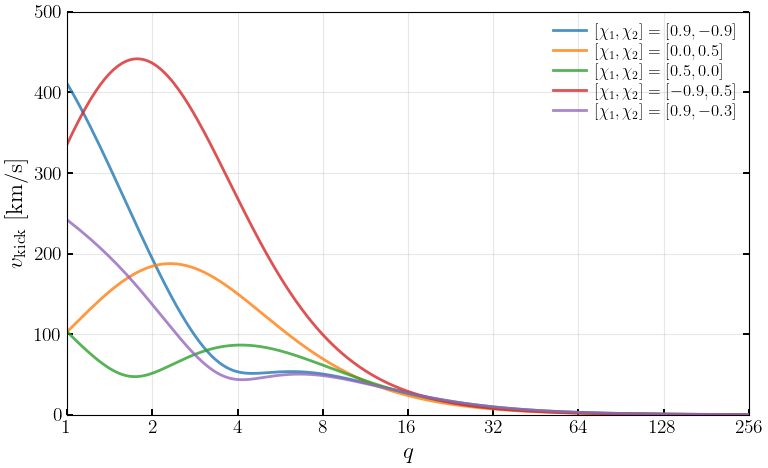

In [3]:
q_arr = np.linspace(1, 256, 5000)

plt.figure(figsize=(8, 5))
for chi1z, chi2z, label in [
    (0.9, -0.9, r'$[\chi_1,\chi_2]=[0.9,-0.9]$'),
    (0.0, 0.5,  r'$[\chi_1,\chi_2]=[0.0,0.5]$'),
    (0.5, 0.0,  r'$[\chi_1,\chi_2]=[0.5,0.0]$'),
    (-0.9, 0.5, r'$[\chi_1,\chi_2]=[-0.9,0.5]$'),
    (0.9, -0.3, r'$[\chi_1,\chi_2]=[0.9,-0.3]$'),
]:
    vk = gwModels.remnants.gwModel_kick_q200(q_arr, chi1z, chi2z)
    plt.plot(np.log2(q_arr), vk, lw=2, alpha=0.8, label=label)

plt.xlabel('$q$')
plt.ylabel(r'$v_{\rm kick}$ [km/s]')
plt.xticks([0, 1, 2, 3, 4, 5, 6, 7, 8], [1, 2, 4, 8, 16, 32, 64, 128, 256])
plt.xlim([0, 8])
plt.ylim([0, 500])
plt.legend(frameon=False)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 2. Aligned-spin GPR kicks : gwModel_kick_q200_GPR

In [4]:
gpr_model = gwModels.remnants.gwModel_kick_q200_GPR('../gwModels/data/gwModel_kick_q200_GPR_aligned_spin.pkl')
gpr_model.info()

gwModel_kick_q200_GPR — GPR aligned-spin kick model
  Islam & Wadekar (2025), https://arxiv.org/abs/2511.11536
  GPR features: [log2(q), chi_hat, chi_a]
  Valid range : {'q': [1, 1000], 'chi1z': [-1, 1], 'chi2z': [-1, 1]}


In [5]:
# Point evaluation
vk_a = gwModels.remnants.gwModel_kick_q200(q=2, chi1z=0.6, chi2z=-0.7)
vk_g, vk_g_std = gpr_model.predict(q=2, chi1z=0.6, chi2z=-0.7)
print(f'Analytical: {vk_a:.2f} km/s')
print(f'GPR: {vk_g[0]:.2f} +/- {vk_g_std[0]:.2f} km/s')

Analytical: 128.97 km/s
GPR: 132.81 +/- 5.52 km/s


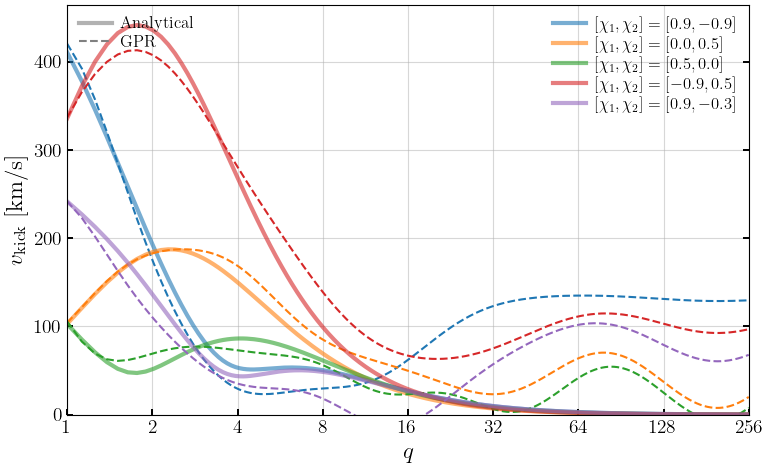

In [6]:
# Comparison: analytical vs GPR across mass ratios
q_plot = np.linspace(1, 256, 2000)

spin_cases = [
    (0.9, -0.9, 'C0'),
    (0.0, 0.5, 'C1'),
    (0.5, 0.0, 'C2'),
    (-0.9, 0.5, 'C3'),
    (0.9, -0.3, 'C4'),
]

plt.figure(figsize=(8, 5))
for chi1z, chi2z, color in spin_cases:
    chi1z_arr = np.full_like(q_plot, chi1z)
    chi2z_arr = np.full_like(q_plot, chi2z)
    
    vk_a = gwModels.remnants.gwModel_kick_q200(q_plot, chi1z_arr, chi2z_arr)
    vk_g, _ = gpr_model.predict(q_plot, chi1z_arr, chi2z_arr)
    
    label = f'$[\\chi_1,\\chi_2]=[{chi1z},{chi2z}]$'
    plt.plot(np.log2(q_plot), vk_a, c=color, lw=3, alpha=0.6, label=label)
    plt.plot(np.log2(q_plot), vk_g, c=color, lw=1.5, ls='--')

legend1 = plt.legend(
    handles=[
        Line2D([0], [0], color='gray', lw=3, alpha=0.6, label='Analytical'),
        Line2D([0], [0], color='gray', lw=1.5, ls='--', label='GPR'),
    ],
    frameon=False, loc='upper left'
)
plt.gca().add_artist(legend1)
plt.legend(frameon=False, loc='upper right')

plt.xlabel('$q$')
plt.ylabel(r'$v_{\rm kick}$ [km/s]')
plt.xticks([0, 1, 2, 3, 4, 5, 6, 7, 8], [1, 2, 4, 8, 16, 32, 64, 128, 256])
plt.xlim([0, 8])
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

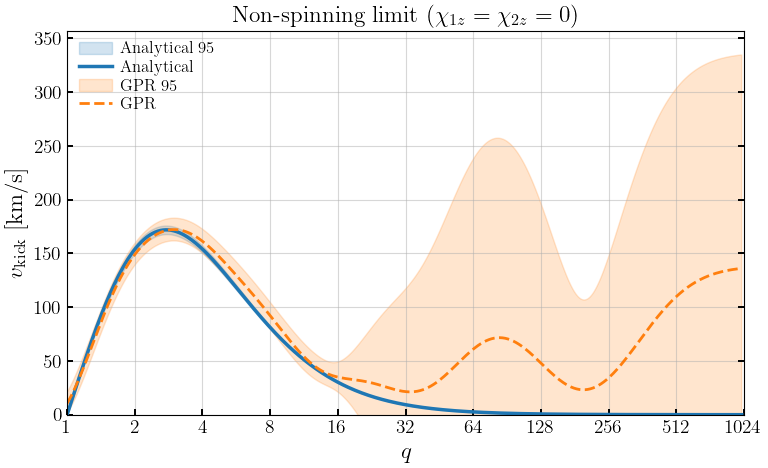

In [7]:
# Non-spinning limit with uncertainty bands
q_ns = np.logspace(0, 3, 500)
zeros = np.zeros_like(q_ns)

vk_a, vk_a_std = gwModels.remnants.gwModel_kick_q200(q_ns, zeros, zeros, return_std=True)
vk_g, vk_g_std = gpr_model.predict(q_ns, zeros, zeros)

plt.figure(figsize=(8, 5))
plt.fill_between(np.log2(q_ns), vk_a - 1.96*vk_a_std, vk_a + 1.96*vk_a_std,
                 alpha=0.2, color='C0', label='Analytical 95% CI')
plt.plot(np.log2(q_ns), vk_a, 'C0', lw=2.5, label='Analytical')
plt.fill_between(np.log2(q_ns), vk_g - 1.96*vk_g_std, vk_g + 1.96*vk_g_std,
                 alpha=0.2, color='C1', label='GPR 95% CI')
plt.plot(np.log2(q_ns), vk_g, 'C1--', lw=2, label='GPR')

plt.xlabel('$q$')
plt.ylabel(r'$v_{\rm kick}$ [km/s]')
plt.xticks([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
           [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024])
plt.xlim([0, 10])
plt.ylim(bottom=0)
plt.legend(frameon=False)
plt.title(r'Non-spinning limit ($\chi_{1z}=\chi_{2z}=0$)')
plt.tight_layout()
plt.show()

### 3. Precessing-spin kicks : gwModel_kick_prec_flow

The flow model samples kick velocity distributions for given $(q, a_1, a_2)$, marginalizing over spin orientation angles.

In [8]:
flow_model = gwModels.remnants.gwModel_kick_prec_flow('../gwModels/data/')
flow_model.info()

gwModel_kick_prec_flow — normalizing-flow kick model for precessing BBH
  Inputs      : q, a1, a2 (spin angles marginalized)
  Flow config : d_in=1, d_hidden=8, d_context=3, n_layers=2


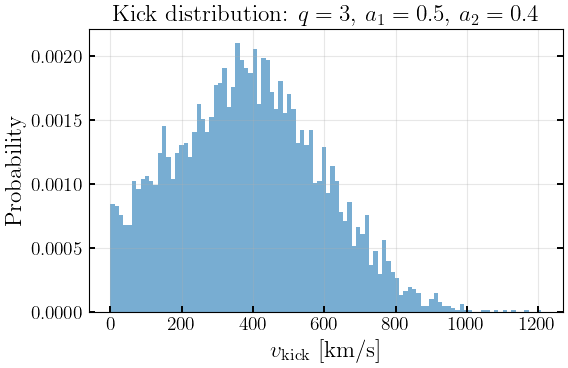

In [9]:
samples = flow_model.sample(q=3, a1=0.5, a2=0.4, num_samples=5000)

plt.figure(figsize=(6, 4))
plt.hist(samples, bins=100, density=True, alpha=0.6)
plt.xlabel(r'$v_{\rm kick}$ [km/s]')
plt.ylabel('Probability')
plt.title(r'Kick distribution: $q=3$, $a_1=0.5$, $a_2=0.4$')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

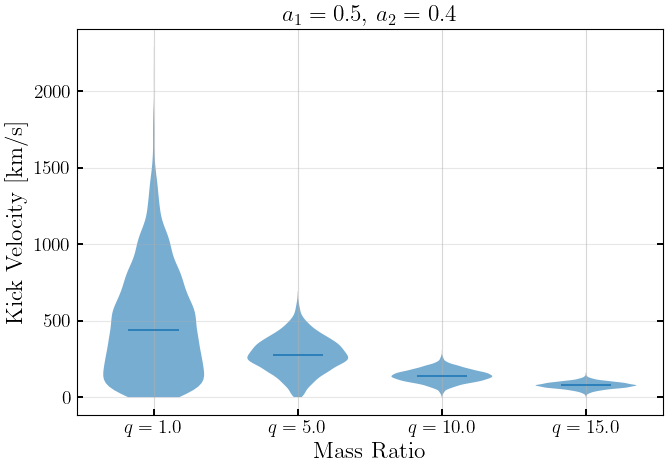

In [10]:
mass_ratios = [1.0, 5.0, 10.0, 15.0]
a1_test, a2_test = 0.5, 0.4

all_samples = []
for q_test in mass_ratios:
    s = flow_model.sample(q=q_test, a1=a1_test, a2=a2_test, num_samples=5000)
    all_samples.append(s)

plt.figure(figsize=(7, 5))
parts = plt.violinplot(all_samples, positions=range(len(mass_ratios)),
                       widths=0.7, showmedians=True, showextrema=False)
for pc in parts['bodies']:
    pc.set_alpha(0.6)
plt.xticks(range(len(mass_ratios)), [f'$q={q}$' for q in mass_ratios])
plt.xlabel('Mass Ratio')
plt.ylabel('Kick Velocity [km/s]')
plt.title(f'$a_1={a1_test}$, $a_2={a2_test}$')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

<!-- batched-flow-demo -->
### 3. Batched sampling and density evaluation

`sample` and `log_prob` accept **array** `(q, a1, a2)` and evaluate the
whole population in a *single* call to the flow — orders of magnitude
faster than looping one binary at a time.

- `sample(q, a1, a2, num_samples=1)` → one kick per binary, shape `(N,)`
  (use `num_samples=M` for `(N, M)`).
- `log_prob(v, q, a1, a2)` → conditional density of the kick *magnitude*;
  it integrates to 1 and is the primitive for inverting the model
  (inferring the progenitor from an observed kick).

batched      : 0.005 s for 20000 binaries  -> shape (20000,)
per-binary   : ~4.2 s (extrapolated)  ->  ~905x slower


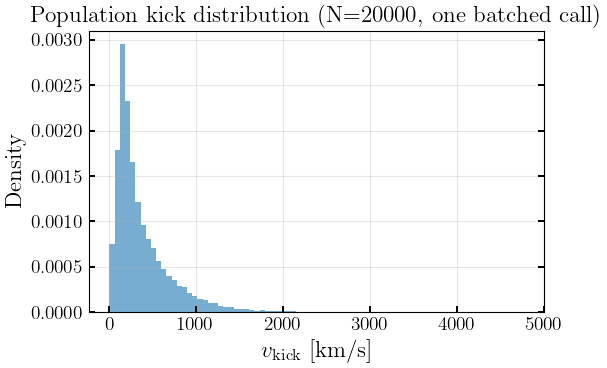

In [11]:
import time

rng = np.random.default_rng(0)
N = 20000
q_pop = rng.uniform(1, 8, N)
a1_pop = rng.uniform(0.05, 1, N)
a2_pop = rng.uniform(0.05, 1, N)

# One batched call: a kick for every binary
t = time.time()
vk = flow_model.sample(q_pop, a1_pop, a2_pop, num_samples=1)
t_batched = time.time() - t

# The slow way (loop over a subset), extrapolated to full N for comparison
t = time.time()
_ = [flow_model.sample(q_pop[i], a1_pop[i], a2_pop[i], num_samples=1)[0]
     for i in range(2000)]
t_loop = (time.time() - t) * (N / 2000)

print(f'batched      : {t_batched:.3f} s for {N} binaries  -> shape {vk.shape}')
print(f'per-binary   : ~{t_loop:.1f} s (extrapolated)  ->  ~{t_loop / t_batched:.0f}x slower')

plt.figure(figsize=(6, 4))
plt.hist(vk, bins=80, density=True, alpha=0.6)
plt.xlabel(r'$v_{\rm kick}$ [km/s]')
plt.ylabel('Density')
plt.title(f'Population kick distribution (N={N}, one batched call)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Conditional density: `log_prob`

`log_prob` returns $\log p(v_{\rm kick}\,|\,q, a_1, a_2)$ for the kick
magnitude. Overlaying it on a histogram of `sample` draws confirms the two
are consistent, and the density integrates to 1.

integral of p(v) dv = 1.000


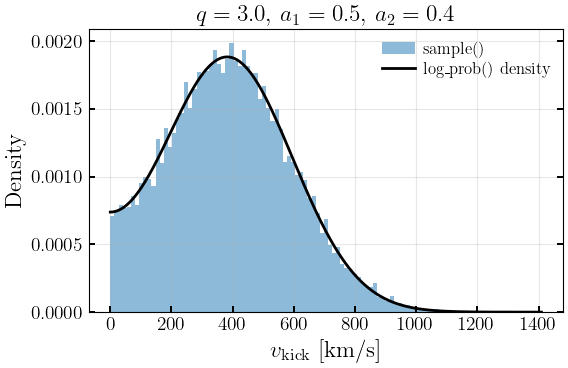

In [12]:
q0, a10, a20 = 3.0, 0.5, 0.4
samples = flow_model.sample(q0, a10, a20, num_samples=20000)

v_grid = np.linspace(0, samples.max() * 1.05, 1000)
pdf = np.exp(flow_model.log_prob(v_grid, q0, a10, a20))

trapz = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz
print(f'integral of p(v) dv = {trapz(pdf, v_grid):.3f}')

plt.figure(figsize=(6, 4))
plt.hist(samples, bins=100, density=True, alpha=0.5, label='sample()')
plt.plot(v_grid, pdf, 'k-', lw=2, label='log_prob() density')
plt.xlabel(r'$v_{\rm kick}$ [km/s]')
plt.ylabel('Density')
plt.title(rf'$q={q0}$, $a_1={a10}$, $a_2={a20}$')
plt.legend(frameon=False)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<!-- gwmodel-vs-hlz-compare -->
### gwmodel vs HLZ on the same population

Both models are evaluated on the *same* array of `(q, a1, a2)`. The flow
(`gwmodel`) marginalises over spin orientation internally; the HLZ /
CLZM2007 formula needs explicit angles, so we draw **isotropic** spin
orientations and a random recoil phase `Theta` for it — making both a
kick distribution over the same population, angles marginalised. We
overlay the distributions and time each (both fully vectorised).

N = 50000 binaries
  gwmodel (flow):   10.61 ms   median  259.9 km/s
  HLZ (CLZM2007):    5.84 ms   median  268.7 km/s


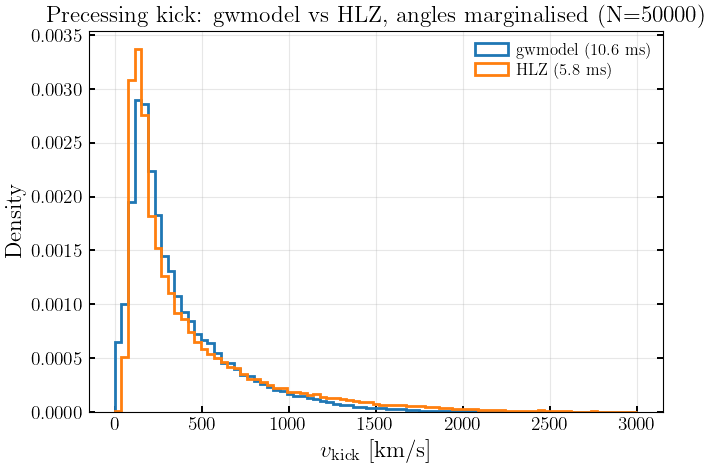

In [13]:
import time

rng = np.random.default_rng(1)
N = 50000
q = rng.uniform(1, 8, N)
a1 = rng.uniform(0.05, 1.0, N)
a2 = rng.uniform(0.05, 1.0, N)

# gwmodel (flow): one batched call, spin angles marginalised internally
t = time.time()
vk_flow = flow_model.sample(q, a1, a2, num_samples=1)
t_flow = time.time() - t

# HLZ (CLZM2007): supply isotropic spin angles + random recoil phase Theta
theta1 = np.arccos(rng.uniform(-1, 1, N))
theta2 = np.arccos(rng.uniform(-1, 1, N))
delta_phi = rng.uniform(0, 2 * np.pi, N)
Theta = rng.uniform(0, 2 * np.pi, N)
t = time.time()
vk_hlz = gwModels.remnants.bbh_final_kick_precessing_CLZM2007(
    q, a1, a2, theta1, theta2, delta_phi, Theta=Theta)
t_hlz = time.time() - t

print(f'N = {N} binaries')
print(f'  gwmodel (flow): {t_flow * 1e3:7.2f} ms   '
      f'median {np.median(vk_flow):6.1f} km/s')
print(f'  HLZ (CLZM2007): {t_hlz * 1e3:7.2f} ms   '
      f'median {np.median(vk_hlz):6.1f} km/s')

bins = np.linspace(0, 3000, 80)
plt.figure(figsize=(7, 5))
plt.hist(vk_flow, bins=bins, density=True, histtype='step', lw=2,
         label=f'gwmodel  ({t_flow * 1e3:.1f} ms)')
plt.hist(vk_hlz, bins=bins, density=True, histtype='step', lw=2,
         label=f'HLZ  ({t_hlz * 1e3:.1f} ms)')
plt.xlabel(r'$v_{\rm kick}$ [km/s]')
plt.ylabel('Density')
plt.title(f'Precessing kick: gwmodel vs HLZ, angles marginalised (N={N})')
plt.legend(frameon=False)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()